# Evaluate the Alignment Algorithm on Real Piano Performances

This notebook evaluates the edit-distance (ED) alignment algorithm in `compareMusic` on real piano performances from the [(n)ASAP dataset](https://github.com/CPJKU/asap-dataset) (Peter, 2023).

(n)ASAP is a dataset of aligned musical scores and performances built by extending the ASAP dataset with note-level annotations. The ASAP contains 236 distinct musical scores and 1067 performances of Western classical piano music from 15 different composers, the piece directory contains the XML and MIDI score, plus all of the performances of a specific piece.

The `note_alignments.tsv` contains official note-level alignment annotations, which can be used as **ground truth**, it uses:
- MusicXML score notes (`xml_id`) as reference
- Performance MIDI notes (`midi_id`) as performance

Therefore, this notebook deliberately loads:
- `xml_score.musicxml` as the pipeline reference
- `midi_performance` as the pipeline response

bib citation:

@article{Peter-2023,
 title = {Automatic Note-Level Score-to-Performance Alignments in the ASAP Dataset},
 author = {Peter, Silvan David and Cancino-Chacón, Carlos Eduardo and Foscarin, Francesco and McLeod, Andrew Philip and Henkel, Florian and Karystinaios, Emmanouil and Widmer, Gerhard},
 doi = {10.5334/tismir.149},
 journal = {Transactions of the International Society for Music Information Retrieval {(TISMIR)}},
 year = {2023}
}

relevant paper: https://transactions.ismir.net/articles/10.5334/tismir.149#5-alignment-of-the-asap-dataset

## Download the (n)ASAP Dataset

In [35]:
import os

# Note: use CPJKU version (not fosfrancesco) because only CPJKU has
# the note_alignments TSV files are needed for ground truth comparison.
if not os.path.exists("asap-dataset"):
    os.system("git clone https://github.com/CPJKU/asap-dataset.git")
else:
    print("asap-dataset already exists, skipping download.")

ASAP_PATH = "asap-dataset"

asap-dataset already exists, skipping download.


## Load the Ground Truth (GT)

The `note_alignment.tsv` file in each performance contains the official note-level alignment annotations. Each row represents one note, with columns: `xml_id`, `midi_id`, `track`, `channel`, `pitch`, `onset`.
- If `midi_id == "deletion"`: the score note was not played → label `deletion`
- If `xml_id == "insertion"`: an extra note was played → label `insertion`
- Otherwise: a matched pair → label `paired`

For `match` and `insertion` rows, the TSV provides `onset` (onset time in seconds) and `pitch` (MIDI pitch) for the performance note.

In [36]:
import csv

def load_ground_truth(tsv_path):
    """
    Read a note_alignment.tsv file from the CPJKU nASAP dataset.
    Returns one dictionary per TSV row. XML and MIDI identifiers are retained
    so that individual alignment errors can be traced later.
        Keys:
            label -> 'paired', 'insertion', or 'deletion'
            xml_id -> score-note identifier, or None for insertions
            midi_id -> performance-note identifier, or None for deletions
            onset -> performance onset in seconds, or None for deletions
            pitch -> performance MIDI pitch, or None for deletions
    """
    rows = []

    with open(tsv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")

        for row in reader:
            xml_id = row["xml_id"].strip()
            midi_id = row["midi_id"].strip()

            if midi_id == "deletion":
                rows.append({
                    "label": "deletion",
                    "xml_id": xml_id,
                    "midi_id": None,
                    "onset": None,
                    "pitch": None,
                })

            elif xml_id == "insertion":
                rows.append({
                    "label": "insertion",
                    "xml_id": None,
                    "midi_id": midi_id,
                    "onset": float(row["onset"]),
                    "pitch": int(row["pitch"]),
                })

            else:
                rows.append({
                    "label": "paired",
                    "xml_id": xml_id,
                    "midi_id": midi_id,
                    "onset": float(row["onset"]),
                    "pitch": int(row["pitch"]),
                })

    return rows

## Load MusicXML (reference) / MIDI Performance (response) pairs

The score reference is loaded from `xml_score.musicxml` with Partitura (https://partitura.readthedocs.io/en/latest/).

The score onset and duration values are kept in symbolic beat units. This is suitable for the current pipeline because it estimates a global timing transformation between the reference and performance. The response remains in seconds because the ground-truth TSV stores performance onsets in seconds.


Helper functions for format conversion:

- `xml_score_to_notes` converts MusicXML score notes into the `{pitch, start, duration}` structure used by `compareMusic`.
- `midi_file_to_notes` converts the performed MIDI into the same structure.

In [37]:
import partitura as pt
import pretty_midi

def xml_score_to_notes(xml_path):
    """
    Parse a MusicXML score into the format used by compareMusic.

    Partitura's note array provides score pitch and symbolic timing.
    Beat-based timing is preferred because it remains meaningful even when
    the MusicXML contains tempo-independent symbolic notation.
    """
    score = pt.load_score(xml_path)
    note_array = score.note_array()

    field_names = set(note_array.dtype.names or [])

    if "onset_beat" in field_names:
        onset_field = "onset_beat"
    elif "onset_quarter" in field_names:
        onset_field = "onset_quarter"
    elif "onset_div" in field_names:
        onset_field = "onset_div"
    else:
        raise KeyError(
            "Could not find an onset field in the Partitura score note array."
        )

    if "duration_beat" in field_names:
        duration_field = "duration_beat"
    elif "duration_quarter" in field_names:
        duration_field = "duration_quarter"
    elif "duration_div" in field_names:
        duration_field = "duration_div"
    else:
        raise KeyError(
            "Could not find a duration field in the Partitura score note array."
        )

    if "pitch" not in field_names:
        raise KeyError("The Partitura score note array has no 'pitch' field.")

    notes = []

    for row in note_array:
        note = {
            "pitch": int(row["pitch"]),
            "start": float(row[onset_field]),
            "duration": float(row[duration_field]),
        }

        # Retain the MusicXML note ID when Partitura supplies it.
        if "id" in field_names:
            note["xml_id"] = str(row["id"])

        notes.append(note)

    notes.sort(key=lambda note: (note["start"], note["pitch"]))
    return notes


def midi_file_to_notes(midi_path):
    """Parse a performance MIDI file into the format used by compareMusic."""
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    all_notes = []

    for instrument in midi_data.instruments:
        if instrument.is_drum:
            continue

        for note in instrument.notes:
            all_notes.append({
                "pitch": int(note.pitch),
                # Keep full precision because rounding may change tolerance-based
                # evaluation near a matching boundary.
                "start": float(note.start),
                "duration": float(note.end - note.start),
            })

    all_notes.sort(key=lambda note: (note["start"], note["pitch"]))
    return all_notes


def build_sample(xml_path, response_path, composer, title, metadata_row):
    """
    Build one MusicXML-score / performance-MIDI sample.

    The score reference and ground-truth TSV now share the same MusicXML
    score-note representation.
    """
    score_notes = xml_score_to_notes(xml_path)
    performance_notes = midi_file_to_notes(response_path)

    if not score_notes or not performance_notes:
        return None

    return {
        "composer": composer,
        "title": title,
        "reference": {"notes": score_notes},
        "response": {"notes": performance_notes},
        "metadata_row": metadata_row,
    }


The nASAP `metadata.csv` gives the path to the MusicXML score, performance MIDI, and note-alignment TSV for each performance. 

In [38]:
def load_samples(asap_path, composer):
    """
    Read metadata.csv and return MusicXML-score / MIDI-performance samples
    for one composer.
    """
    metadata_path = os.path.join(asap_path, "metadata.csv")
    samples = []

    with open(metadata_path, "r", encoding="utf-8") as csv_file:
        reader = csv.DictReader(csv_file)

        for row in reader:
            if row.get("composer", "").strip() != composer:
                continue

            xml_path = os.path.join(asap_path, row.get("xml_score", "").strip())
            response_path = os.path.join(asap_path, row.get("midi_performance", "").strip())
            tsv_path = os.path.join(asap_path, row.get("note_alignments", "").strip())
            
            if os.path.isfile(xml_path) and os.path.isfile(response_path) and os.path.isfile(tsv_path):
                sample = build_sample(
                xml_path,
                response_path,
                row.get("composer", "Unknown"),
                row.get("title", "Unknown"),
                dict(row),
            )
                if sample is not None:
                    samples.append(sample)

    return samples

samples = load_samples(ASAP_PATH, "Bach")

print("Loaded", len(samples), "MusicXML-score (reference) / MIDI-performance (response) pairs.")

/Users/jz7125/compareMusic/.venv/lib/python3.13/site-packages/partitura/directions.py:526: UserWarning: error parsing "(   )" (UnexpectedCharacters)
  warnings.warn('error parsing "{}" ({})'.format(string, type(e).__name__))
/Users/jz7125/compareMusic/.venv/lib/python3.13/site-packages/partitura/io/importmusicxml.py:1112: UserWarning: ignoring direction type: metronome {'parentheses': 'no', 'default-x': '-51.17', 'relative-y': '20.00'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))


Loaded 169 MusicXML-score (reference) / MIDI-performance (response) pairs.


# Run Alignment on Each Pair

Each score/performance pair is passed through `compare_performance_ED`. The current pipeline normalises the first onset to zero and groups nearby notes into events. Because `event_details` stores event indices, the same normalisation and grouping steps are reproduced here tso that the correct onset and pitch for each event during ground truth comparison can be looked up.

The original response onset offset is retained and added back only during comparison with the absolute performance times in the TSV file.

In [39]:
from evaluation_function.compare_MIDI import (
    compare_performance_ED,
    normalize_start_times,
    group_notes_into_events,
)


def run_alignment_on_samples(samples):
    """Run compare_performance_ED for every loaded sample."""
    results = []

    for sample_index, sample in enumerate(samples):
        result = compare_performance_ED(
            sample["response"],
            sample["reference"],
        )

        response_notes_normalized = normalize_start_times(
            sample["response"]["notes"]
        )
        response_events_normalized = group_notes_into_events(
            response_notes_normalized
        )

        ref_notes_normalized = normalize_start_times(
            sample["reference"]["notes"]
        )
        ref_events_normalized = group_notes_into_events(
            ref_notes_normalized
        )

        response_onset_offset = float(
            sample["response"]["notes"][0]["start"]
        )

        results.append({
            "sample_index": sample_index,
            "composer": sample["composer"],
            "title": sample["title"],
            "metadata_row": sample["metadata_row"],
            "stats": result.stats,
            "event_details": result.event_details,
            "is_correct": result.is_correct,
            "response_events_normalized": response_events_normalized,
            "ref_events_normalized": ref_events_normalized,
            "response_onset_offset": response_onset_offset,
        })

    return results


all_results = run_alignment_on_samples(samples)
print("Alignment complete for", len(all_results), "pieces.")

Alignment complete for 169 pieces.


## Compute Precision, Recall, and F1 

**Pipeline output vs ground truth**

he GT has three different labels, while our pipeline has four operations:

| Pipeline operation | GT label | Explanation |
|---|---|---|
| `match` | `paired` | Same pitch — GT still calls this `paired` |
| `replacement` | `paired` | Different pitch — GT still calls this `paired`, because the score note *was* played at approximately the right time |
| `missing` | `deletion` | Score note not found in response |
| `extra` | `insertion` | Response note has no score counterpart |

**Evaluation metrics design**

Evaluation is performed at **note level** after expanding chord events. Matches are one-to-one, so three notes at the same chord onset remain three separate observations.

| Label | Matching key | TP | FP | FN |
|---|---|---|---|---|
| `paired` (pipeline `match` / `replacement`) | onset-only matching within `ONSET_TOLERANCE`; pitch is intentionally ignored because this evaluates alignment rather than pitch correctness| Pipeline and ground truth both contain a paired label at matching performance onsets within the tolerance | Pipeline predicts a pairing at this onset that the ground truth does not recognise | Ground truth expects a pairing at this onset that the pipeline fails to find |
| `deletion` (pipeline `missing`) | count only as no onset or pitch available for deletions | Overlap between the pipeline deletion count and the ground-truth deletion count | The pipeline predicts more deletions than appear in the ground truth; the excess count is treated as FP | The ground truth contains more deletions than the pipeline predicts; the missing count is treated as FN |
| `insertion` (pipeline `extra`) | pitch must be equal and onset must be within `ONSET_TOLERANCE` | Pipeline and ground truth agree an extra, unexpected note was played at this pitch and onset | Pipeline flags a note as extra that the ground truth does not agree with | Ground truth marks a note as extra that the pipeline fails to identify |

- Precision: TP / (TP + FP), i.e. of all labels the pipeline predicted, how many were correct  
- Recall: TP / (TP + FN), i.e. of all GT labels, how many the pipeline found  
- F1: the harmonic mean of precision and recall 

In [40]:
def convert_pipeline_output(event_details, response_events, ref_events):
    """
    Convert event-level alignment output into note-level alignment labels.
    Alignment labels describe note correspondence, not pitch correctness.

    Rules:
        missing:
            Every note in the reference event becomes a deletion.
        extra:
            Every note in the response event becomes an insertion.
        match/replacement:
            Pair as many response and reference notes as possible.
            Different pitches may still form a paired alignment.
            Remaining response notes become insertions.
            Remaining reference notes become deletions.

    This implementation guarantees:
        paired + insertion == total response notes
        paired + deletion == total reference notes
    """
    predictions = []

    for event in event_details:
        operation = event["operation_type"]

        response_event = None
        reference_event = None

        if event.get("response_index") is not None:
            response_index = event["response_index"] - 1
            if (response_index < 0) or (response_index >= len(response_events)):
                raise IndexError("response_index is outside response_events")
            response_event = response_events[response_index]

        if event.get("reference_index") is not None:
            reference_index = event["reference_index"] - 1
            if (reference_index < 0) or (reference_index >= len(ref_events)):
                raise IndexError("reference_index is outside ref_events")
            reference_event = ref_events[reference_index]

        # for missing event
        if operation == "missing":
            for reference_note in reference_event["notes"]:
                predictions.append({
                    "onset": None,
                    "pitch": None,
                    "label": "deletion",
                })
        # for extra event
        elif operation == "extra":
            for response_note in response_event["notes"]:
                predictions.append({
                    "onset": float(response_note["start"]),
                    "pitch": int(response_note["pitch"]),
                    "label": "insertion",
                })
        # for matched or replacement event
        else:
            response_notes = sorted(
                response_event["notes"],
                key=lambda note: int(note["pitch"])
            )
            reference_notes = sorted(
                reference_event["notes"],
                key=lambda note: int(note["pitch"])
            )
            pair_count = min(len(response_notes), len(reference_notes))

            # A pitch difference does not change the alignment label:
            # it remains paired.
            for index in range(pair_count):
                response_note = response_notes[index]
                predictions.append({
                    "onset": float(response_note["start"]),
                    "pitch": int(response_note["pitch"]),
                    "label": "paired",
                })

            # Response side contains more notes.
            for response_note in response_notes[pair_count:]:
                predictions.append({
                    "onset": float(response_note["start"]),
                    "pitch": int(response_note["pitch"]),
                    "label": "insertion",
                })

            # Reference side contains more notes.
            missing_count = len(reference_notes) - pair_count
            for i in range(missing_count):
                predictions.append({
                    "onset": None,
                    "pitch": None,
                    "label": "deletion",
                })

    return predictions

In [41]:
ONSET_TOLERANCE = 0.05  # 50 milliseconds

def count_onset_matches(gt_onsets, predicted_onsets, tolerance):
    """Count one-to-one onset matches while preserving chord notes."""
    gt_onsets = sorted(gt_onsets)
    predicted_onsets = sorted(predicted_onsets)

    gt_index = 0
    predicted_index = 0
    matches = 0

    while gt_index < len(gt_onsets) and predicted_index < len(predicted_onsets):
        difference = predicted_onsets[predicted_index] - gt_onsets[gt_index]

        if abs(difference) <= tolerance:
            matches += 1
            gt_index += 1
            predicted_index += 1
        elif difference < -tolerance:
            predicted_index += 1
        else:
            gt_index += 1

    return matches

In [42]:
def compute_metrics(ground_truth, predictions, onset_offset=0.0):
    """Compute note-level precision, recall, and F1."""
    total_tp = 0
    total_fp = 0
    total_fn = 0

    # 1. Paired notes: compare onset only.
    gt_paired = [
        row["onset"]
        for row in ground_truth
        if row["label"] == "paired" and row["onset"] is not None
    ]
    predicted_paired = [
        row["onset"] + onset_offset
        for row in predictions
        if row["label"] == "paired" and row["onset"] is not None
    ]

    paired_tp = count_onset_matches(
        gt_paired, predicted_paired, ONSET_TOLERANCE
    )
    total_tp += paired_tp
    total_fp += len(predicted_paired) - paired_tp
    total_fn += len(gt_paired) - paired_tp

    # 2. Insertions: compare both pitch and onset.
    gt_insertions = {}
    predicted_insertions = {}

    for row in ground_truth:
        if (
            row["label"] == "insertion"
            and row["pitch"] is not None
            and row["onset"] is not None
        ):
            pitch = int(row["pitch"])
            if pitch not in gt_insertions:
                gt_insertions[pitch] = []
            gt_insertions[pitch].append(float(row["onset"]))

    for row in predictions:
        if (
            row["label"] == "insertion"
            and row["pitch"] is not None
            and row["onset"] is not None
        ):
            pitch = int(row["pitch"])
            if pitch not in predicted_insertions:
                predicted_insertions[pitch] = []
            predicted_insertions[pitch].append(
                float(row["onset"]) + onset_offset
            )

    for pitch in set(gt_insertions) | set(predicted_insertions):
        gt_onsets = gt_insertions.get(pitch, [])
        predicted_onsets = predicted_insertions.get(pitch, [])

        insertion_tp = count_onset_matches(
            gt_onsets,
            predicted_onsets,
            ONSET_TOLERANCE,
        )
        total_tp += insertion_tp
        total_fp += len(predicted_onsets) - insertion_tp
        total_fn += len(gt_onsets) - insertion_tp

    # 3. Deletions: count-based because the pipeline does not return xml_id.
    gt_deletions = sum(
        row["label"] == "deletion" for row in ground_truth
    )
    predicted_deletions = sum(
        row["label"] == "deletion" for row in predictions
    )

    deletion_tp = min(gt_deletions, predicted_deletions)
    total_tp += deletion_tp
    total_fp += predicted_deletions - deletion_tp
    total_fn += gt_deletions - deletion_tp

    precision = (
        total_tp / (total_tp + total_fp)
        if total_tp + total_fp > 0 else 0.0
    )
    recall = (
        total_tp / (total_tp + total_fn)
        if total_tp + total_fn > 0 else 0.0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
    }

## Evaluate all pieces

The evaluation is note-level. Notes inside a chord are kept as separate notes. Paired notes use a 50 ms onset tolerance, while insertions require both the same MIDI pitch and a matching onset.

In [43]:
import pandas as pd

evaluation_rows = []

for sample, result in zip(samples, all_results):
    metadata_row = sample["metadata_row"]
    tsv_relative_path = (metadata_row.get("note_alignments") or "").strip()
    tsv_path = os.path.join(ASAP_PATH, tsv_relative_path)

    if not os.path.isfile(tsv_path):
        print("TSV not found:", tsv_path)
        continue

    ground_truth = load_ground_truth(tsv_path)
    predictions = convert_pipeline_output(
        result["event_details"],
        result["response_events_normalized"],
        result["ref_events_normalized"],
    )

    metrics = compute_metrics(
        ground_truth,
        predictions,
        onset_offset=result["response_onset_offset"],
    )

    evaluation_rows.append({
        "Piece": f'{result["composer"]} ({result["title"]})',
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "TP": metrics["tp"],
        "FP": metrics["fp"],
        "FN": metrics["fn"],
    })

df_eval = pd.DataFrame(evaluation_rows)
print(df_eval.sort_values("Precision", ascending=True).head(10).round(4))

print("Median Precision:", round(df_eval["Precision"].median(), 4))
print("Median Recall   :", round(df_eval["Recall"].median(), 4))
print("Median F1       :", round(df_eval["F1"].median(), 4))

                       Piece  Precision  Recall      F1    TP   FP   FN
153   Bach (Prelude_bwv_885)     0.8389  0.8903  0.8638   479   92   59
134   Bach (Prelude_bwv_874)     0.8941  0.9249  0.9092  1477  175  120
135   Bach (Prelude_bwv_874)     0.9012  0.9345  0.9176  1469  161  103
86   Bach (Italian_concerto)     0.9016  0.9330  0.9170  1100  120   79
84   Bach (Italian_concerto)     0.9031  0.9325  0.9175  1146  123   83
110   Bach (Prelude_bwv_858)     0.9111  0.9204  0.9157   451   44   39
76      Bach (Fugue_bwv_889)     0.9126  0.9126  0.9126   783   75   75
152   Bach (Prelude_bwv_885)     0.9129  0.9384  0.9255   503   48   33
77      Bach (Fugue_bwv_889)     0.9134  0.9189  0.9161   770   73   68
108   Bach (Prelude_bwv_857)     0.9143  0.9437  0.9288   587   55   35
Median Precision: 0.9803
Median Recall   : 0.9821
Median F1       : 0.9807


### Interpretation of results

In [44]:
SELECTED_SAMPLE_INDEX = 153

selected_sample = samples[SELECTED_SAMPLE_INDEX]
selected_result = all_results[SELECTED_SAMPLE_INDEX]

ref_events = selected_result["ref_events_normalized"]
response_events = selected_result["response_events_normalized"]
event_details = selected_result["event_details"]

metadata_row = selected_sample["metadata_row"]

tsv_path = os.path.join(ASAP_PATH, metadata_row["note_alignments"].strip())
xml_path = os.path.join(ASAP_PATH, metadata_row["xml_score"].strip())
midi_score_path = os.path.join(ASAP_PATH, metadata_row["midi_score"].strip())
midi_performance_path = os.path.join(ASAP_PATH, metadata_row["midi_performance"].strip())

ground_truth = load_ground_truth(tsv_path)

predictions = convert_pipeline_output(
    selected_result["event_details"],
    selected_result["response_events_normalized"],
    selected_result["ref_events_normalized"],
)

# Add the original response onset offset back.
for prediction in predictions:
    if prediction["onset"] is not None:
        prediction["onset"] += selected_result["response_onset_offset"]

print("Piece:", selected_result["composer"], selected_result["title"])
print("Ground-truth labels:", len(ground_truth))
print("Pipeline labels:", len(predictions))


from collections import Counter
gt_counts = Counter(note["label"] for note in ground_truth)
pipeline_counts = Counter(note["label"] for note in predictions)

gt_response_note_count = gt_counts["paired"] + gt_counts["insertion"]
gt_reference_note_count = gt_counts["paired"] + gt_counts["deletion"]
pipeline_response_note_count = pipeline_counts["paired"] + pipeline_counts["insertion"]
pipeline_reference_note_count = pipeline_counts["paired"] + pipeline_counts["deletion"]

actual_response_event_note_count = sum(len(event["notes"]) for event in response_events)
actual_reference_event_note_count = sum(len(event["notes"]) for event in ref_events)

print("=== Ground truth ===")
print("Paired:", gt_counts["paired"])
print("Insertion:", gt_counts["insertion"])
print("Deletion:", gt_counts["deletion"])
print("Performance notes represented:", gt_response_note_count)
print("Reference notes represented:", gt_reference_note_count)

print("=== Pipeline predictions ===")
print("Paired:", pipeline_counts["paired"])
print("Insertion:", pipeline_counts["insertion"])
print("Deletion:", pipeline_counts["deletion"])
print("Performance notes represented:", pipeline_response_note_count)
print("Reference notes represented:", pipeline_reference_note_count)

print("=== Original event data ===")
print("Notes in response_events:", actual_response_event_note_count)
print("Notes in ref_events:", actual_reference_event_note_count)

print("=== Conservation checks ===")
print(
    "Every response note represented exactly once:",
    pipeline_response_note_count
    == actual_response_event_note_count
)
print(
    "Every reference note represented exactly once:",
    pipeline_reference_note_count
    == actual_reference_event_note_count
)

Piece: Bach Prelude_bwv_885
Ground-truth labels: 538
Pipeline labels: 571
=== Ground truth ===
Paired: 497
Insertion: 28
Deletion: 13
Performance notes represented: 525
Reference notes represented: 510
=== Pipeline predictions ===
Paired: 464
Insertion: 61
Deletion: 46
Performance notes represented: 525
Reference notes represented: 510
=== Original event data ===
Notes in response_events: 525
Notes in ref_events: 510
=== Conservation checks ===
Every response note represented exactly once: True
Every reference note represented exactly once: True


The pipeline produced 571 note-level labels while the the GT has 538 labels. Specifically, the pipeline predicted 33 more insertions, 33 more deletions and 33 fewer pairs than the GT. This is because 'paired' can be represented by a single label whereas 'unpaired' requires both an insertion and a deletion. The paper (Peter, 2023) suggests that a misalignment pair (which is unaligned in GT) will create one FP and two FNs (i.e. label as paired instead of a deletion + an insertion). In this case here, it appears as the reverse: a GT paired correspondence is split into a predicted insertion and deletion, such an error can produce two FPs and one FN, which helps explain why precision is lower than recall in this case.

As the ground truth is chosen to be the result of another alignment algorithm, the metrics actually measures the agreement between the existing alignment algorithm and mine, rather than absolute musical correctness. This occurrence of FPs and FNs is likely related to the alignment strategy (based on pitch difference) and parameter settings, and it appears that my pipeline with default parameters favours gap operations (insertion/deletion) rather than pairing up 2 notes (match/replacement). In educational applications, pairing a wrong note with its intended score note may provide more informative feedback than treating the same event as an insertion and a deletion. The default parameters are set to be strict, but my pipeline allows teachers to adjust parameters so that the this alignment can be adapted to different musical contexts. For example, the gap penalty and timing thresholds can be adjusted depending on whether the target application is beginner practice, examination recordings or expert concert performances. 

Additionally, the nASAP contains performances data from a competition, consequently, the dataset contains expressive timing, tempo fluctuations and ornament that are less representative of beginner practice, makes it differ substantially from the intended application of this project—providing feedback for student practice. (However, this is the most suitable public dataset to use, so the lacking of large-scale students' practice data remains the biggest limitation of this project).

Bach Prelude_bwv_885


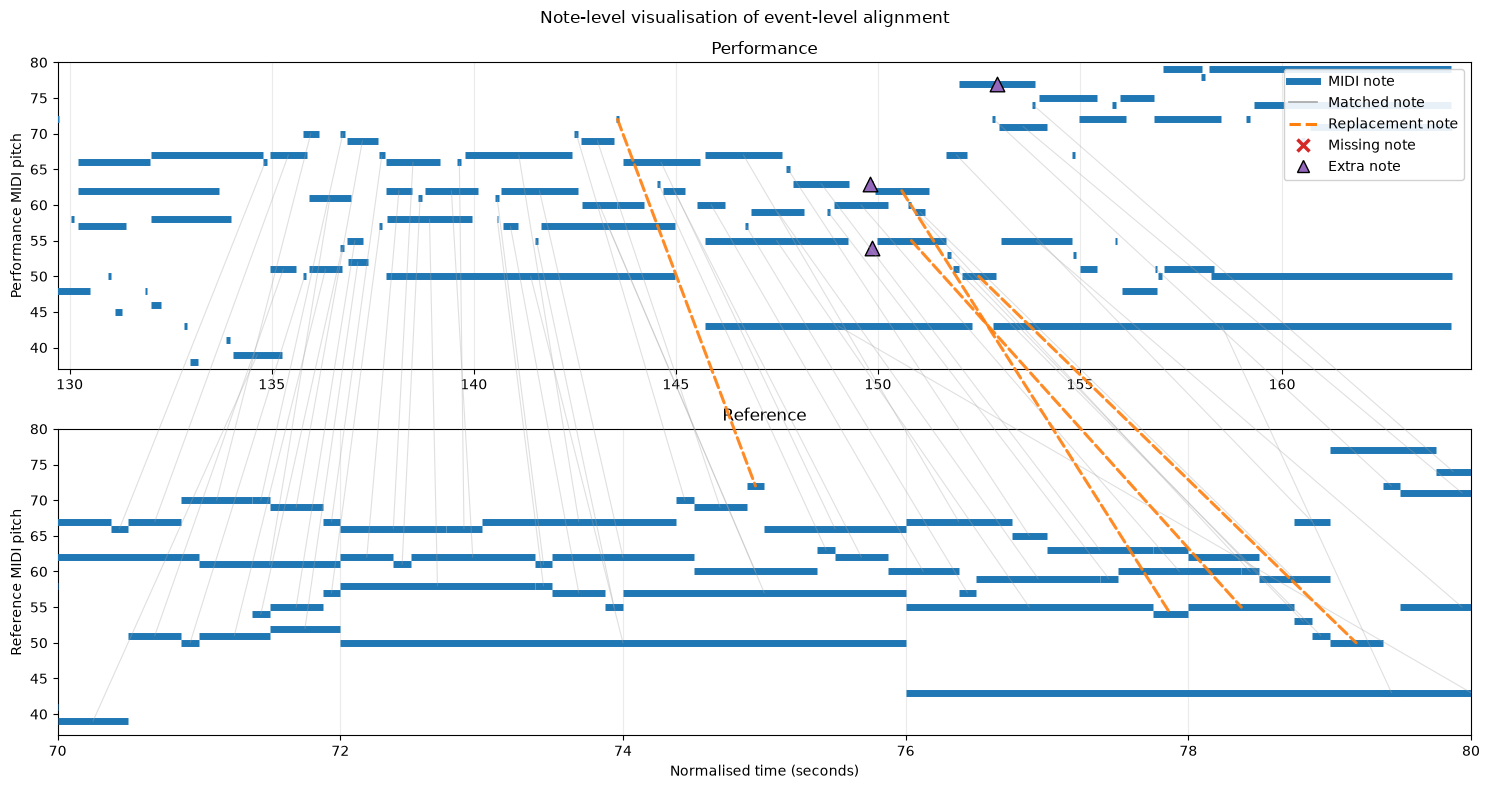

Selected operations: 48
Note connectors: 59
Missing note markers: 0
Extra note markers: 3


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D

SELECTED_SAMPLE_INDEX = 153

selected_result = all_results[SELECTED_SAMPLE_INDEX]
ref_events = selected_result["ref_events_normalized"]
response_events = selected_result["response_events_normalized"]
event_details = selected_result["event_details"]

print(selected_result["composer"], selected_result["title"])

def get_note_centre(note):
    return (
        note["start"] + note["duration"] / 2,
        note["pitch"],
    )

def event_overlaps_range(event, start, end):
    for note in event["notes"]:
        note_start = note["start"]
        note_end = note["start"] + note["duration"]
        if note_end >= start and note_start <= end:
            return True
    return False

def pair_event_notes(ref_event, response_event):
    """
    Pair notes inside two aligned events for plotting.

    Rules:
        1. Pair notes with the same pitch first.
        2. Pair remaining notes in ascending pitch order.
        3. If the events contain different numbers of notes, only pair
           as many notes as possible.
    """
    ref_notes = sorted(
        ref_event["notes"],
        key=lambda note: (note["pitch"], note["start"]),
    )

    response_notes = sorted(
        response_event["notes"],
        key=lambda note: (note["pitch"], note["start"]),
    )

    note_pairs = []

    used_ref_indices = set()
    used_response_indices = set()

    # First pair notes with identical pitches.
    for response_index, response_note in enumerate(response_notes):
        matching_ref_index = None

        for ref_index, ref_note in enumerate(ref_notes):
            ref_is_available = ref_index not in used_ref_indices
            pitches_match = ref_note["pitch"] == response_note["pitch"]

            if ref_is_available and pitches_match:
                matching_ref_index = ref_index

        if matching_ref_index is not None:
            note_pairs.append(
                (
                    ref_notes[matching_ref_index],
                    response_note,
                )
            )

            used_ref_indices.add(matching_ref_index)
            used_response_indices.add(response_index)

    # Collect notes that were not paired by pitch.
    remaining_ref_notes = []

    for ref_index, ref_note in enumerate(ref_notes):
        if ref_index not in used_ref_indices:
            remaining_ref_notes.append(ref_note)

    remaining_response_notes = []

    for response_index, response_note in enumerate(response_notes):
        if response_index not in used_response_indices:
            remaining_response_notes.append(response_note)

    # Pair the remaining notes by ascending pitch.
    remaining_pair_count = min(
        len(remaining_ref_notes),
        len(remaining_response_notes),
    )

    for pair_index in range(remaining_pair_count):
        note_pairs.append(
            (
                remaining_ref_notes[pair_index],
                remaining_response_notes[pair_index],
            )
        )

    return note_pairs


def plot_alignment(ref_events, response_events, event_details, ref_start, ref_end):
    reference_positions = []

    for position, detail in enumerate(event_details):
        reference_index = detail.get("reference_index")

        if reference_index is not None:
            ref_event = ref_events[reference_index - 1]

            if event_overlaps_range(
                ref_event,
                ref_start,
                ref_end,
            ):
                reference_positions.append(position)

    if not reference_positions:
        raise ValueError(
            "No reference events were found in this range."
        )

    first_position = min(reference_positions)
    last_position = max(reference_positions)

    selected_details = []

    for position in range(first_position, last_position + 1):
        detail = event_details[position]
        operation = detail["operation_type"]
        reference_index = detail.get("reference_index")

        include_detail = operation == "extra"

        if reference_index is not None:
            ref_event = ref_events[reference_index - 1]

            if event_overlaps_range(ref_event, ref_start, ref_end):
                include_detail = True

        if include_detail:
            selected_details.append(detail)

    response_starts = []
    response_ends = []

    for detail in selected_details:
        response_index = detail.get("response_index")

        if response_index is not None:
            response_event = response_events[response_index - 1]

            for note in response_event["notes"]:
                response_starts.append(note["start"])
                response_ends.append(note["start"] + note["duration"])

    if response_starts:
        response_start = min(response_starts) - 0.5
        response_end = max(response_ends) + 0.5
    else:
        response_start = ref_start
        response_end = ref_end

    visible_response_events = []
    for event in response_events:
        if event_overlaps_range(event, response_start, response_end):
            visible_response_events.append(event)

    visible_ref_events = []
    for event in ref_events:
        if event_overlaps_range(event, ref_start, ref_end):
            visible_ref_events.append(event)

    visible_pitches = []
    for event in visible_response_events:
        for note in event["notes"]:
            visible_pitches.append(note["pitch"])
    for event in visible_ref_events:
        for note in event["notes"]:
            visible_pitches.append(note["pitch"])

    fig, (ax_response, ax_ref) = plt.subplots(2, 1,
        figsize=(15, 8), height_ratios=[1, 1])

    note_colour = "tab:blue"
    match_colour = "0.65"
    replacement_colour = "tab:orange"
    missing_colour = "tab:red"
    extra_colour = "tab:purple"

    # Draw performance piano roll.
    for event in visible_response_events:
        for note in event["notes"]:
            ax_response.hlines(
                y=note["pitch"],
                xmin=note["start"],
                xmax=note["start"] + note["duration"],
                linewidth=5,
                color=note_colour,
                zorder=3,
            )

    ax_response.set_xlim(response_start, response_end)
    ax_response.set_ylabel("Performance MIDI pitch")
    ax_response.set_title("Performance")

    # Draw reference piano roll.
    for event in visible_ref_events:
        for note in event["notes"]:
            ax_ref.hlines(
                y=note["pitch"],
                xmin=note["start"],
                xmax=note["start"] + note["duration"],
                linewidth=5,
                color=note_colour,
                zorder=3,
            )

    ax_ref.set_xlim(ref_start, ref_end)
    ax_ref.set_xlabel("Normalised time (seconds)")
    ax_ref.set_ylabel("Reference MIDI pitch")
    ax_ref.set_title("Reference")

    if visible_pitches:
        pitch_min = min(visible_pitches) - 1
        pitch_max = max(visible_pitches) + 1
        ax_response.set_ylim(pitch_min, pitch_max)
        ax_ref.set_ylim(pitch_min, pitch_max)

    connector_count = 0

    # Draw one connector for every paired note.
    for detail in selected_details:
        operation = detail["operation_type"]
        reference_index = detail.get("reference_index")
        response_index = detail.get("response_index")

        both_events_exist = (
            reference_index is not None
            and response_index is not None
        )

        if both_events_exist:
            ref_event = ref_events[reference_index - 1]
            response_event = response_events[response_index - 1]

            note_pairs = pair_event_notes(ref_event, response_event)

            if operation == "match":
                line_style = "-"
                line_width = 0.8
                line_alpha = 0.35
                line_colour = match_colour
            else:
                line_style = "--"
                line_width = 2.2
                line_alpha = 0.9
                line_colour = replacement_colour

            for ref_note, response_note in note_pairs:
                ref_x, ref_y = get_note_centre(ref_note)

                response_x, response_y = get_note_centre(response_note)

                response_visible = (
                    response_start
                    <= response_x
                    <= response_end
                )

                reference_visible = (
                    ref_start
                    <= ref_x
                    <= ref_end
                )

                if response_visible and reference_visible:
                    connector = ConnectionPatch(
                        xyA=(response_x, response_y),
                        coordsA=ax_response.transData,
                        xyB=(ref_x, ref_y),
                        coordsB=ax_ref.transData,
                        linestyle=line_style,
                        linewidth=line_width,
                        color=line_colour,
                        alpha=line_alpha,
                        clip_on=False,
                        zorder=2,
                    )

                    fig.add_artist(connector)
                    connector_count += 1

    missing_count = 0
    extra_count = 0

    for detail in selected_details:
        operation = detail["operation_type"]

        if operation == "missing":
            reference_index = detail.get("reference_index")

            if reference_index is not None:
                ref_event = ref_events[reference_index - 1]

                for note in ref_event["notes"]:
                    marker_x, marker_y = get_note_centre(note)

                    if ref_start <= marker_x <= ref_end:
                        ax_ref.scatter(
                            marker_x,
                            marker_y,
                            marker="x",
                            s=130,
                            linewidths=3,
                            color=missing_colour,
                            zorder=10,
                        )

                        missing_count += 1

        elif operation == "extra":
            response_index = detail.get("response_index")

            if response_index is not None:
                response_event = response_events[
                    response_index - 1
                ]

                for note in response_event["notes"]:
                    marker_x, marker_y = get_note_centre(note)

                    if (
                        response_start
                        <= marker_x
                        <= response_end
                    ):
                        ax_response.scatter(
                            marker_x,
                            marker_y,
                            marker="^",
                            s=110,
                            color=extra_colour,
                            edgecolors="black",
                            linewidths=1,
                            zorder=10,
                        )

                        extra_count += 1

    legend_items = [
        Line2D([0], [0], color=note_colour, linewidth=5, label="MIDI note"),
        Line2D([0], [0], color=match_colour, linestyle="-", linewidth=1.2, label="Matched note"),
        Line2D([0], [0], color=replacement_colour, linestyle="--", 
               linewidth=2.2, label="Replacement note"),
        Line2D([0], [0], color=missing_colour, marker="x", linestyle="None", 
               markersize=9, markeredgewidth=2.5, label="Missing note"),
        Line2D([0], [0], color=extra_colour, marker="^", markeredgecolor="black",
               linestyle="None", markersize=9, label="Extra note"),
    ]

    ax_response.legend(handles=legend_items, loc="upper right", framealpha=0.9)
    ax_response.grid(axis="x", alpha=0.25)
    ax_ref.grid(axis="x", alpha=0.25)
    fig.suptitle("Note-level visualisation of event-level alignment")
    plt.tight_layout()
    plt.show()

    print("Selected operations:", len(selected_details))
    print("Note connectors:", connector_count)
    print("Missing note markers:", missing_count)
    print("Extra note markers:", extra_count)


plot_alignment(ref_events, response_events, event_details, ref_start=70.0, ref_end=80.0)

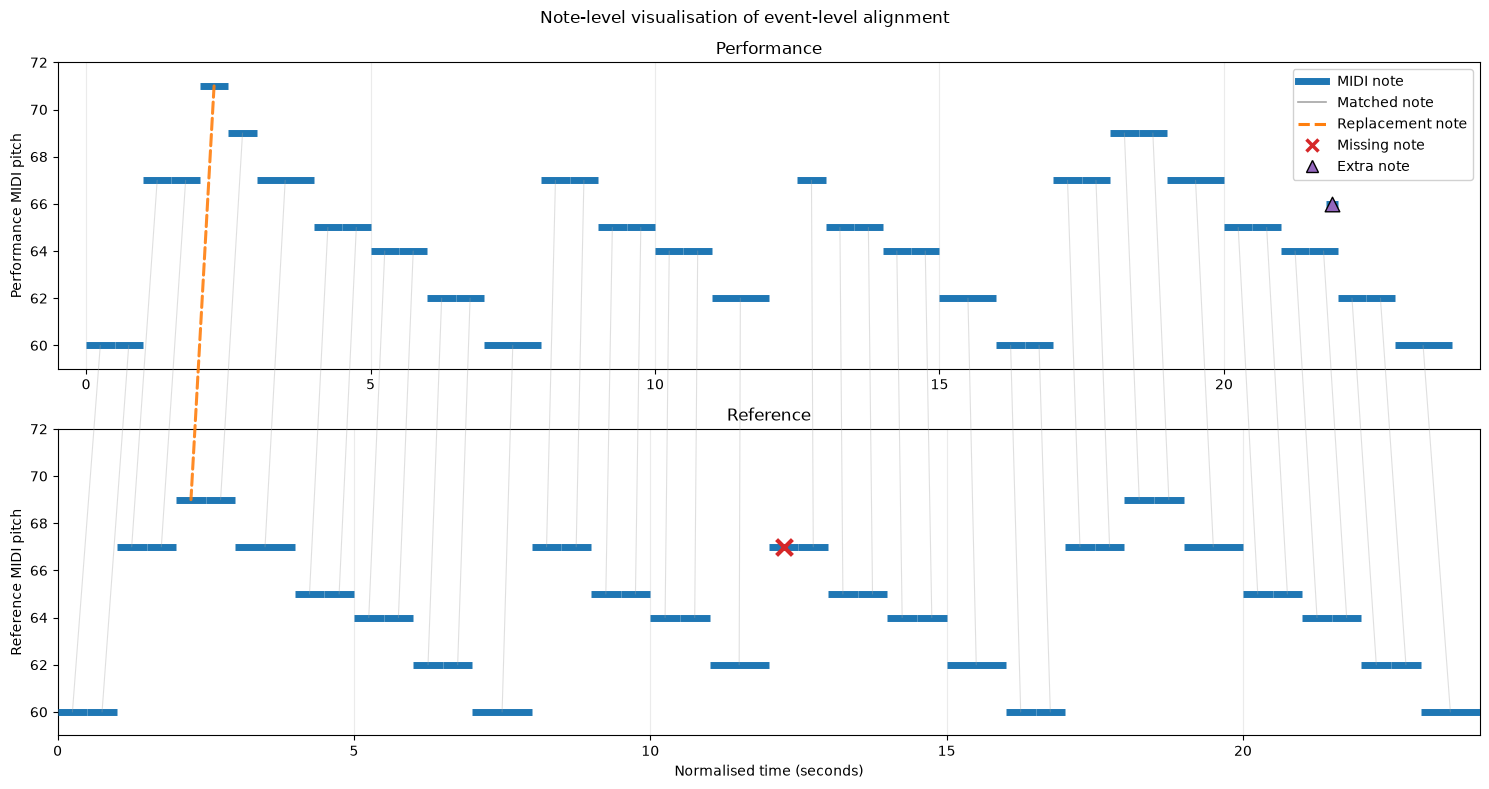

Selected operations: 43
Note connectors: 41
Missing note markers: 1
Extra note markers: 1


In [ ]:
import json

with open("../data/longMIDIsequence.json", "r") as file:
    test_data = json.load(file)

twinkle_case = None

for case in test_data["test_cases"]:
    if case["name"] == "twinkle_scattered_errors":
        twinkle_case = case

twinkle_result = compare_performance_ED(twinkle_case["response"], twinkle_case["reference"])

twinkle_ref_notes = normalize_start_times(twinkle_case["reference"]["notes"])
twinkle_response_notes = normalize_start_times(twinkle_case["response"]["notes"])

twinkle_ref_events = group_notes_into_events(twinkle_ref_notes)
twinkle_response_events = group_notes_into_events(twinkle_response_notes)
twinkle_event_details = twinkle_result.event_details

def plot_case(ax_response, ax_ref, fig, ref_events, response_events, event_details, ref_start, ref_end, title):
    selected_details = []

    for detail in event_details:
        reference_index = detail.get("reference_index")

        if reference_index is not None:
            ref_event = ref_events[reference_index - 1]

            if event_overlaps_range(ref_event, ref_start, ref_end):
                selected_details.append(detail)

    selected_positions = []

    for position, detail in enumerate(event_details):
        if detail in selected_details:
            selected_positions.append(position)

    if selected_positions:
        first_position = min(selected_positions)
        last_position = max(selected_positions)

        for position in range(first_position, last_position + 1):
            detail = event_details[position]

            if detail["operation_type"] == "extra" and detail not in selected_details:
                selected_details.append(detail)

    response_starts = []
    response_ends = []

    for detail in selected_details:
        response_index = detail.get("response_index")

        if response_index is not None:
            response_event = response_events[response_index - 1]

            for note in response_event["notes"]:
                response_starts.append(note["start"])
                response_ends.append(note["start"] + note["duration"])

    if response_starts:
        response_start = min(response_starts) - 0.2
        response_end = max(response_ends) + 0.2
    else:
        response_start = ref_start
        response_end = ref_end

    visible_ref_events = []
    visible_response_events = []
    visible_pitches = []

    for event in ref_events:
        if event_overlaps_range(event, ref_start, ref_end):
            visible_ref_events.append(event)

    for event in response_events:
        if event_overlaps_range(event, response_start, response_end):
            visible_response_events.append(event)

    for event in visible_ref_events:
        for note in event["notes"]:
            visible_pitches.append(note["pitch"])

    for event in visible_response_events:
        for note in event["notes"]:
            visible_pitches.append(note["pitch"])

    note_colour = "tab:blue"
    match_colour = "0.65"
    replacement_colour = "tab:orange"
    missing_colour = "tab:red"
    extra_colour = "tab:purple"

    for event in visible_response_events:
        for note in event["notes"]:
            ax_response.hlines(note["pitch"], note["start"], note["start"] + note["duration"], linewidth=5, color=note_colour)

    for event in visible_ref_events:
        for note in event["notes"]:
            ax_ref.hlines(note["pitch"], note["start"], note["start"] + note["duration"], linewidth=5, color=note_colour)

    ax_response.set_xlim(response_start, response_end)
    ax_ref.set_xlim(ref_start, ref_end)

    if visible_pitches:
        pitch_min = min(visible_pitches) - 1
        pitch_max = max(visible_pitches) + 1
        ax_response.set_ylim(pitch_min, pitch_max)
        ax_ref.set_ylim(pitch_min, pitch_max)

    for detail in selected_details:
        operation = detail["operation_type"]
        reference_index = detail.get("reference_index")
        response_index = detail.get("response_index")

        if reference_index is not None and response_index is not None:
            ref_event = ref_events[reference_index - 1]
            response_event = response_events[response_index - 1]
            note_pairs = pair_event_notes(ref_event, response_event)

            if operation == "match":
                line_colour = match_colour
                line_style = "-"
                line_width = 0.8
                line_alpha = 0.4
            else:
                line_colour = replacement_colour
                line_style = "--"
                line_width = 2
                line_alpha = 0.9

            for ref_note, response_note in note_pairs:
                ref_x, ref_y = get_note_centre(ref_note)
                response_x, response_y = get_note_centre(response_note)

                connector = ConnectionPatch(
                    xyA=(response_x, response_y),
                    coordsA=ax_response.transData,
                    xyB=(ref_x, ref_y),
                    coordsB=ax_ref.transData,
                    color=line_colour,
                    linestyle=line_style,
                    linewidth=line_width,
                    alpha=line_alpha,
                    clip_on=False
                )

                fig.add_artist(connector)

        if operation == "missing" and reference_index is not None:
            ref_event = ref_events[reference_index - 1]

            for note in ref_event["notes"]:
                x, y = get_note_centre(note)
                ax_ref.scatter(x, y, marker="x", s=120, linewidths=3, color=missing_colour, zorder=10)

        if operation == "extra" and response_index is not None:
            response_event = response_events[response_index - 1]

            for note in response_event["notes"]:
                x, y = get_note_centre(note)
                ax_response.scatter(x, y, marker="^", s=100, color=extra_colour, edgecolors="black", zorder=10)

    ax_response.set_title(title)
    ax_response.grid(axis="x", alpha=0.2)
    ax_ref.grid(axis="x", alpha=0.2)
    ax_ref.set_xlabel("Time (s)")

plot_alignment(
    twinkle_ref_events,
    twinkle_response_events,
    twinkle_event_details,
    ref_start=0.0,
    ref_end=24.0
)

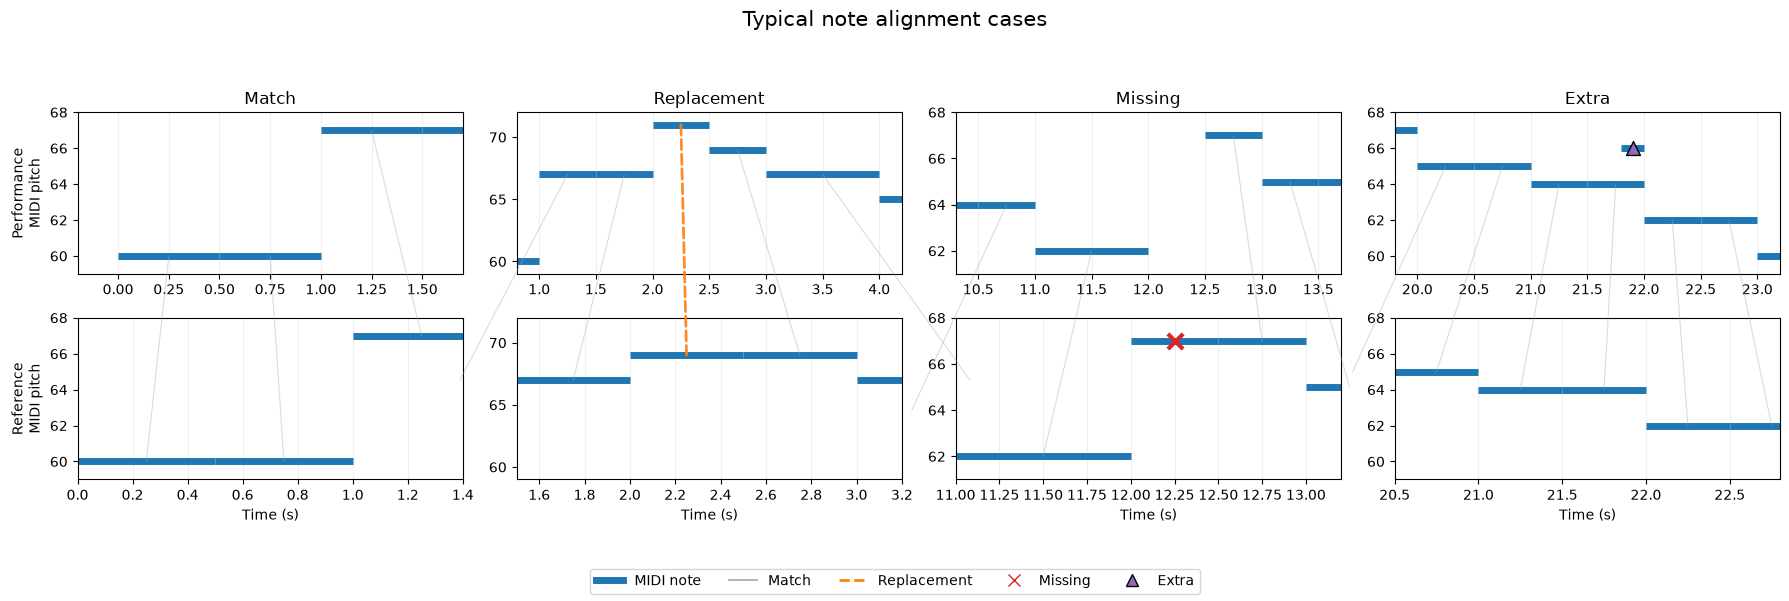

In [60]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6))

cases = [
    ("Match", 0.0, 1.4),
    ("Replacement", 1.5, 3.2),
    ("Missing", 11.0, 13.2),
    ("Extra", 20.5, 22.8)
]

for column, case in enumerate(cases):
    title = case[0]
    ref_start = case[1]
    ref_end = case[2]

    plot_case(
        axes[0, column],
        axes[1, column],
        fig,
        twinkle_ref_events,
        twinkle_response_events,
        twinkle_event_details,
        ref_start,
        ref_end,
        title
    )

axes[0, 0].set_ylabel("Performance\nMIDI pitch")
axes[1, 0].set_ylabel("Reference\nMIDI pitch")

legend_items = [
    Line2D([0], [0], color="tab:blue", linewidth=5, label="MIDI note"),
    Line2D([0], [0], color="0.65", linewidth=1.2, label="Match"),
    Line2D([0], [0], color="tab:orange", linestyle="--", linewidth=2, label="Replacement"),
    Line2D([0], [0], color="tab:red", marker="x", linestyle="None", markersize=9, label="Missing"),
    Line2D([0], [0], color="tab:purple", marker="^", markeredgecolor="black", linestyle="None", markersize=9, label="Extra")
]

fig.legend(handles=legend_items, loc="lower center", ncol=5)
fig.suptitle("Typical note alignment cases", fontsize=15)

plt.tight_layout(rect=[0, 0.1, 1, 0.93])
plt.show()

## limitation

- The evaluation uses the nASAP note-alignment benchmark, which is designed to evaluate the alignment results of between music score and expert performance during competitions. In contrast, the objective of this project is to generate educational feedback for student practice, however, there is no large-scale public dataset contains students' practice MIDI and references. 

- The default alignment parameters (e.g., gap penalty, timing tolerance and chord onset window) were chosen empirically and may not be optimal for all musical styles, therefore these parameters are designed to be allowed for configuration.

- My alignment algorithm is event-level, however, the grouping of chords currently relies on a fixed onset threshold, identification of broken chords (Arpeggios), ornaments and other highly expressive performance strategies are left as future work.